# The Opportunity Score

**Where in Spain is there a real tourism problem worth acting on?**

A region scores high when **two things are true at the same time**: a lot of tourism happens
there, *and* visitors complain about one thing more than they do elsewhere. Neither alone is
a problem.

```
A.  rate     = negative mentions / all mentions     for one region, one aspect
B.  z        = (rate − average region) / spread     within that one aspect
C.  driver   = the aspect with the highest z        ← this region's problem
D.  signal   = erf(z / √2), and 0 if z ≤ 0          0 … 1
E.  pressure = how busy the region is               0 … 1
F.  score    = pressure × signal × 100              0 … 100
```

**In:** two parquet files in `../Session 11/data/raw/` — reviews with aspect + sentiment
(Role 1), official tourism indicators (Role 4). Never modified.

**Out:** four CSVs in `output/` — the ranking and the monthly view, each written twice:
English column names for code, Spanish column names for the write-up and for Role 6.
`DICCIONARIO.md` explains every column.

The design is closed: the window is 2019-01 to 2025-12 and the formula does not change again.

**Pick the `mlenv` kernel and Run All.** About a minute.

In [1]:
# ── SETTINGS — the only lines you ever need to change ──────────────────────────
MIN_MENTIONS = 50                      # below this, a region-aspect cannot be a driver
WINDOW       = ("2019-01", "2025-12")  # the final window, declared in Session 12
FEW_NEGATIVE = 20                      # fewer complaints than this gets flagged "thin"
CLOSE_GAP    = 0.25                    # top two aspects closer than this in z = a near tie

DATA_DIR      = "../Session 11/data/raw"
REVIEWS_FILE  = "absa_resultados_completo_v3.parquet"                    # Role 1
OFFICIAL_FILE = "R4_PANEL_CANDIDATOS_INDICE_CCAA_MES_2019_2025.parquet"  # Role 4
PRESSURE_COL  = "regulated_overnights_per_1000_residents__position_pct"

# Spanish names for every column we write. Step 6 stops with an error if one is missing,
# so a new column can never ship unnamed. No accents: they break in Excel and Power BI.
COLUMNAS_ES = {
    "rank": "puesto",                  "ccaa": "ccaa",
    "score": "puntuacion",             "pressure": "presion_turistica",
    "driver_aspect": "aspecto_motor",  "z": "z",
    "signal": "senal",                 "mentions": "menciones",
    "negatives": "negativas",          "negative_rate": "tasa_negativa",
    "evidence": "evidencia",           "driver_2": "aspecto_2",
    "z_2": "z_2",                      "signal_2": "senal_2",
    "mentions_2": "menciones_2",       "negatives_2": "negativas_2",
    "negative_rate_2": "tasa_negativa_2", "evidence_2": "evidencia_2",
    "z_gap": "diferencia_z",           "driver_is_close": "empate_tecnico",
    "n_rankable_aspects": "aspectos_evaluables",
    "period": "periodo",               "average_region": "media_regiones",
    "spread": "dispersion",
}

# ── setup ──────────────────────────────────────────────────────────────────────
from pathlib import Path
from math import erf, sqrt
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

RAW = Path(DATA_DIR).resolve()
OUT = Path.cwd() / "output"
OUT.mkdir(parents=True, exist_ok=True)
FIRST, LAST = WINDOW

for f in (REVIEWS_FILE, OFFICIAL_FILE):
    print(f"{'found  ' if (RAW / f).exists() else 'MISSING'}  {f}")
print("\nwriting to:", OUT)

found    absa_resultados_completo_v3.parquet
found    R4_PANEL_CANDIDATOS_INDICE_CCAA_MES_2019_2025.parquet

writing to: /Users/husseinelsaadi/Documents/Preply/Students/Jervin/Session 13/output


## Step 1 — Look at the raw data

One row of the reviews file = **one aspect found in one fragment of one review**.
*"lovely view, but noisy"* becomes two rows: `vistas / positivo` and `descanso_ruido / negativo`.

One row of the official file = **one region in one month**, with how much tourism happened.

In [2]:
reviews_raw = pd.read_parquet(
    RAW / REVIEWS_FILE,
    columns=["review_id", "ccaa", "period", "aspecto", "frase", "sentimiento"])

print(f"REVIEWS  {len(reviews_raw):,} rows from {reviews_raw.review_id.nunique():,} reviews")
print(f"         {reviews_raw.ccaa.nunique()} regions, {reviews_raw.period.nunique()} months "
      f"({reviews_raw.period.min()} to {reviews_raw.period.max()})")
print(f"         sentiment: {reviews_raw.sentimiento.value_counts().to_dict()}\n")
print("mentions per aspect:")
print(reviews_raw.aspecto.value_counts().to_string())

official_raw = pd.read_parquet(RAW / OFFICIAL_FILE, columns=["ccaa", "period", PRESSURE_COL])
print(f"\nOFFICIAL {len(official_raw):,} rows = "
      f"{official_raw.ccaa.nunique()} regions x {official_raw.period.nunique()} months")
print("same 19 region names on both sides:",
      set(reviews_raw.ccaa.unique()) == set(official_raw.ccaa.unique()))

REVIEWS  4,099,623 rows from 1,996,719 reviews


         19 regions, 84 months (2019-01 to 2025-12)
         sentiment: {'positivo': 3648047, 'neutro': 338496, 'negativo': 113080}

mentions per aspect:
aspecto
trato_anfitrion          1214623
ubicacion                1018446
equipamiento              660219
limpieza                  362697
descanso_ruido            243665
aparcamiento              146393
desayuno_restauracion     145103
autenticidad              137098
vistas                     85939
precio                     82705
masificacion                2735

OFFICIAL 1,596 rows = 19 regions x 84 months


same 19 region names on both sides: True


In [3]:
# HEALTH CHECK: when one fragment carries two aspects, do they ever disagree?
fragment = (reviews_raw[reviews_raw.duplicated("frase", keep=False)]
            .groupby("frase").agg(aspects=("aspecto", "nunique"),
                                  labels=("sentimiento", "nunique")))
many     = fragment[fragment.aspects >= 2]
disagree = (many.labels >= 2).mean()

print(f"fragments holding 2+ aspects : {len(many):,}")
print(f"...of those, how many disagree: {disagree:.2%}\n")
print("GOOD - the sentiment really is per aspect." if disagree > 0.01 else
      "PROBLEM - one label per fragment is copied onto every aspect in it, so the\n"
      "          sentiment is NOT per aspect. Role 1's to fix. The score below is\n"
      "          still built correctly; its input is what is weak.")
del fragment, many

fragments holding 2+ aspects : 679,075
...of those, how many disagree: 0.00%

PROBLEM - one label per fragment is copied onto every aspect in it, so the
          sentiment is NOT per aspect. Role 1's to fix. The score below is
          still built correctly; its input is what is weak.


## Step 2 — Combine the two files

1. **Count each person once.** Four sentences about cleanliness is still *one* opinion, so we
   keep one row per `review × aspect` — the **worst** sentiment of the ones they gave.
2. **Keep the window**, 2019-01 to 2025-12.
3. **Add up to region × aspect**: how many mentioned it, how many were negative.
4. **Also keep region × month × aspect** — the same counting, not yet collapsed over time.
   Step 5 needs it, and doing it here means we never read the 4-million-row file twice.
5. **Tourism pressure** comes straight from the official file, averaged over the window. It is
   a fact about the region and must not depend on how many reviews we happened to collect.

In [4]:
# 1. one row per review x aspect, keeping the worst sentiment
worst_first = {"negativo": 0, "neutro": 1, "positivo": 2}
one_per_person = (reviews_raw
    .sort_values("sentimiento", key=lambda col: col.map(worst_first))
    .drop_duplicates(["review_id", "aspecto"]))

# 2. keep only the declared window
in_window = one_per_person[one_per_person.period.between(FIRST, LAST)]
in_window = in_window.assign(is_negative=in_window.sentimiento == "negativo")

# 3 + 4. the same counting at two levels of detail
area = (in_window.groupby(["ccaa", "aspecto"], as_index=False)
        .agg(mentions=("is_negative", "size"), negatives=("is_negative", "sum")))
monthly = (in_window.groupby(["ccaa", "period", "aspecto"], as_index=False)
           .agg(mentions=("is_negative", "size"), negatives=("is_negative", "sum")))

# 5. tourism pressure, from the official file only
official = official_raw.rename(columns={PRESSURE_COL: "pressure"})
official = official[official.period.between(FIRST, LAST)].copy()
official["pressure"] = official.pressure / 100          # a 0-100 position becomes 0-1
area["pressure"] = area.ccaa.map(official.groupby("ccaa").pressure.mean())

# a published blank is unknown, not a zero - so it is skipped, never filled
blanks = official.groupby("ccaa").pressure.count()
blanks = blanks[blanks < official.period.nunique()]
if len(blanks):
    print("official file has blanks - these regions are averaged over fewer months:")
    print(blanks.to_string(), "\n")

TOTAL_MENTIONS = len(in_window)
del reviews_raw, one_per_person, in_window
print(f"{TOTAL_MENTIONS:,} mentions in the window")
print(f"region x aspect        : {len(area)} rows")
print(f"region x month x aspect: {len(monthly):,} rows")
area.head()

official file has blanks - these regions are averaged over fewer months:
ccaa
Ceuta      82
Melilla    82 

3,639,688 mentions in the window
region x aspect        : 208 rows
region x month x aspect: 9,475 rows


,ccaa,aspecto,mentions,negatives,pressure
0,Andalucía,aparcamiento,37837,1302,0.760099
1,Andalucía,autenticidad,31701,305,0.760099
2,Andalucía,desayuno_restauracion,28270,1148,0.760099
3,Andalucía,descanso_ruido,42717,1520,0.760099
4,Andalucía,equipamiento,112107,5957,0.760099


## Step 3 — Calculate the score

### Why not just use the negative rate

Aspects are complained about at completely different rates. Nationally `masificacion` runs
about **9%** negative and `ubicacion` about **0.6%** — thirteen times apart. "The aspect with
the highest negative rate" would give nearly the same answer for every region, because it is
telling us about the *aspect*, not the *region*.

**The fix:** for each aspect, ask how much regions actually differ on it, then describe each
region as *how far above the average region it is, in those units*. That is the `z`. It makes
an unusual `vistas` number and an unusual `limpieza` number mean the same thing.

`erf(z/√2)` then turns `z` into a 0–1 signal — `z` of 1 → 0.68, of 2 → 0.95, of 3 → 0.997 —
so one extreme region cannot run away with the score. A region at or below average gets
exactly **0**: it is above average on nothing, and the index says so rather than inventing a
rank for it.

### Two guards on the evidence

- **50 mentions** to be eligible as a driver at all.
- Fewer than **20 actual complaints** gets flagged `thin` — still ranked, but the flag travels
  into the CSV so nobody quotes it by accident.

### One driver, with the runner-up reported beside it

Blending the top two aspects 60/40 was tested and rejected: it changed nothing
(rank correlation 0.958, same top 5) and it can only ever *lower* a score, punishing a region
for having one clear problem instead of two. So the score keeps one driver — and the CSV
carries `driver_2`, `z_2`, `z_gap` and `driver_is_close` so a near tie is visible. Where the
gap is under **0.25**, name both aspects.

In [5]:
area["negative_rate"] = area.negatives / area.mentions                  # A. rate
area["can_rank"]      = area.mentions >= MIN_MENTIONS
area["evidence"]      = np.where(area.negatives >= FEW_NEGATIVE, "solid", "thin")

# B. z — how far above the average region, in this aspect's own units
yardstick = area[area.can_rank].groupby("aspecto").negative_rate.agg(["mean", "std"])
area = area.join(yardstick, on="aspecto")
area["z"] = np.where(area.can_rank, (area.negative_rate - area["mean"]) / area["std"], np.nan)

# D. signal — z as a 0-1 number, and 0 for anything not above average
area["signal"] = [erf(v / sqrt(2)) if v > 0 else 0.0 for v in area.z.fillna(-1)]
area.loc[~area.can_rank, "signal"] = np.nan

# C. rank the eligible aspects inside each region: 1st = driver, 2nd = runner-up
eligible = area[area.can_rank].sort_values(["ccaa", "z"], ascending=[True, False])
eligible = eligible.assign(place=eligible.groupby("ccaa").cumcount() + 1)

keep   = ["ccaa", "aspecto", "z", "signal", "mentions", "negatives", "negative_rate", "evidence"]
first  = eligible[eligible.place == 1][keep + ["pressure"]].rename(
             columns={"aspecto": "driver_aspect"})
second = eligible[eligible.place == 2][keep].rename(columns={
             "aspecto": "driver_2", "z": "z_2", "signal": "signal_2", "mentions": "mentions_2",
             "negatives": "negatives_2", "negative_rate": "negative_rate_2",
             "evidence": "evidence_2"})

score = first.merge(second, on="ccaa", how="left")
score["n_rankable_aspects"] = score.ccaa.map(eligible.groupby("ccaa").size())
score["score"]           = score.pressure * score.signal * 100          # F. score
score["z_gap"]           = score.z - score.z_2
score["driver_is_close"] = score.z_gap < CLOSE_GAP                      # no runner-up -> False

score = score.sort_values("score", ascending=False).reset_index(drop=True)
score.insert(0, "rank", range(1, len(score) + 1))
score = score[["rank", "ccaa", "score", "pressure",
               "driver_aspect", "z", "signal", "mentions", "negatives", "negative_rate",
               "evidence", "driver_2", "z_2", "signal_2", "mentions_2", "negatives_2",
               "negative_rate_2", "evidence_2", "z_gap", "driver_is_close",
               "n_rankable_aspects"]]
score.to_csv(OUT / "opportunity_score.csv", index=False)
print(f"wrote output/opportunity_score.csv  -  {len(score)} regions, {score.shape[1]} columns\n")

score[["rank", "ccaa", "score", "pressure", "driver_aspect", "z", "mentions", "negatives",
       "evidence", "driver_2", "z_gap", "driver_is_close"]]

wrote output/opportunity_score.csv  -  19 regions, 21 columns



,rank,ccaa,score,pressure,driver_aspect,z,mentions,negatives,evidence,driver_2,z_gap,driver_is_close
0,1,Canarias,93.420077,0.946484,desayuno_restauracion,2.484383,3220,289,solid,precio,0.617964,False
1,2,Illes Balears,76.678350,0.855558,precio,1.626882,3540,349,solid,vistas,1.477371,False
2,3,Cantabria,61.675601,0.672048,precio,1.737644,727,73,solid,masificacion,0.861600,False
3,4,Aragón,59.559683,0.710932,masificacion,1.397609,56,7,thin,descanso_ruido,0.603852,False
4,5,Comunidad Foral de Navarra,55.890307,0.579979,autenticidad,2.093106,121,6,thin,aparcamiento,0.673528,False
5,6,Cataluña,48.264526,0.799830,precio,0.847771,12898,1106,solid,trato_anfitrion,1.134445,False
6,7,Comunidad de Madrid,47.032333,0.490712,vistas,2.038006,11944,241,solid,masificacion,1.603441,False
7,8,Región de Murcia,34.018981,0.341847,limpieza,2.816929,764,119,solid,equipamiento,0.377511,False
8,9,Castilla y León,33.942330,0.543602,vistas,0.886027,1578,24,solid,desayuno_restauracion,0.011395,True
9,10,La Rioja,32.995521,0.473942,autenticidad,1.028304,139,5,thin,descanso_ruido,0.297780,False


## Step 4 — See the result

The **bar chart** is the answer. The **heatmap** is the working behind it: every region against
every aspect, so you can see why each got the driver it did, and how close the runner-up was.

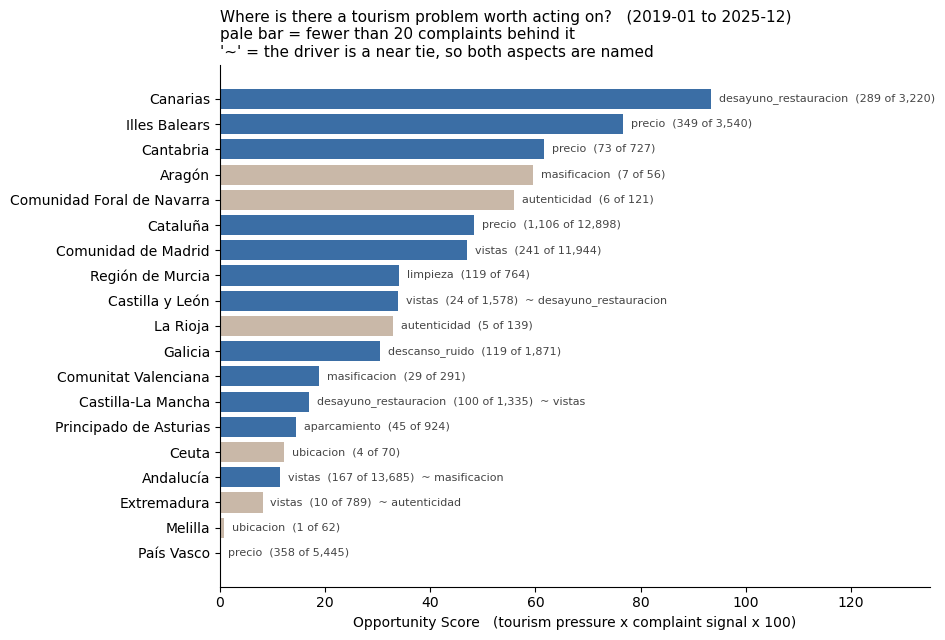

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 6.5))
d = score.sort_values("score")
colour = np.where(d.evidence == "thin", "#c9b8a8", "#3b6ea5")
ax.barh(d.ccaa, d.score, color=colour)

for y, r in enumerate(d.itertuples()):
    label = f"{r.driver_aspect}  ({r.negatives:,} of {r.mentions:,})"
    if r.driver_is_close:
        label += f"  ~ {r.driver_2}"          # a near tie: name both
    ax.text(r.score + 1.5, y, label, va="center", fontsize=8, color="#444")

ax.set_xlim(0, 135)
ax.set_xlabel("Opportunity Score   (tourism pressure x complaint signal x 100)")
ax.set_title(f"Where is there a tourism problem worth acting on?   ({FIRST} to {LAST})\n"
             f"pale bar = fewer than {FEW_NEGATIVE} complaints behind it\n"
             f"'~' = the driver is a near tie, so both aspects are named",
             fontsize=11, loc="left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


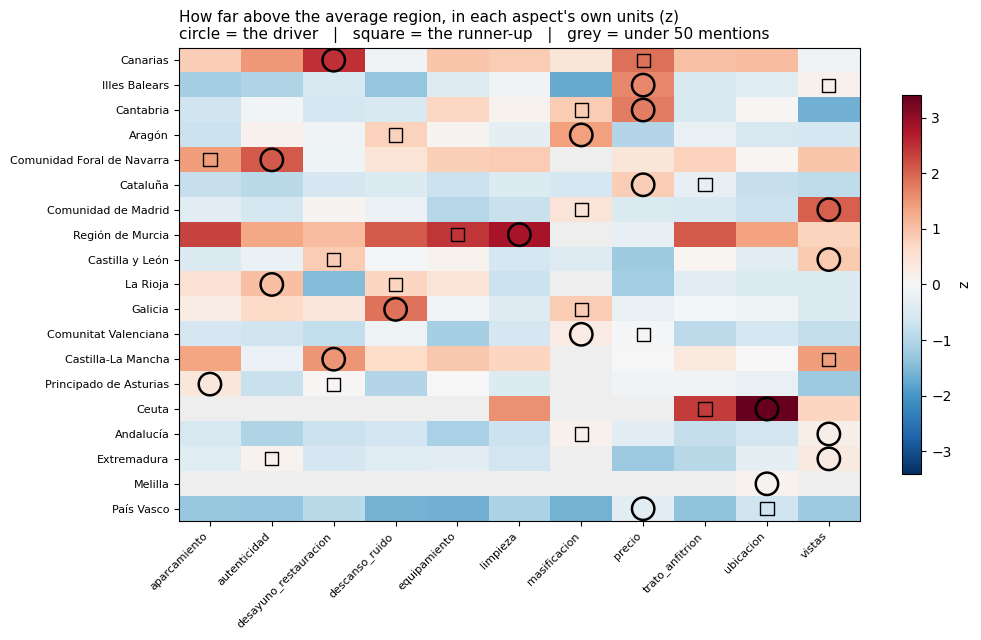

In [7]:
grid = area.pivot(index="ccaa", columns="aspecto", values="z").loc[score.ccaa]
colours = plt.get_cmap("RdBu_r").copy()
colours.set_bad("#eeeeee")                       # grey = under 50 mentions, not eligible

fig, ax = plt.subplots(figsize=(10.5, 6.5))
limit = np.nanmax(np.abs(grid.values))
im = ax.imshow(grid, cmap=colours, vmin=-limit, vmax=limit, aspect="auto")
ax.set_xticks(range(grid.shape[1]), grid.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(grid.shape[0]), grid.index, fontsize=8)

col = {a: i for i, a in enumerate(grid.columns)}
runner_up = score.dropna(subset=["driver_2"])

ax.scatter([col[a] for a in score.driver_aspect], range(len(grid)),          # the driver
           s=260, facecolors="none", edgecolors="black", linewidths=1.8)
ax.scatter([col[a] for a in runner_up.driver_2], runner_up.index,            # the runner-up
           s=90, marker="s", facecolors="none", edgecolors="black", linewidths=1.0)

ax.set_title("How far above the average region, in each aspect's own units (z)\n"
             "circle = the driver   |   square = the runner-up   |   grey = under 50 mentions",
             fontsize=11, loc="left")
fig.colorbar(im, ax=ax, shrink=.8, label="z")
plt.tight_layout(); plt.show()


## Step 5 — The same score, month by month

The same formula, applied to one month at a time. Two things are **frozen**, and that is the
whole reason it is readable:

- **The driver aspect.** Each region keeps the aspect Step 3 gave it. Letting each month pick
  its own was tested: only 2 of 17 regions kept the aspect their own pooled data chose.
  A trend line only means something if the thing being tracked holds still.
- **The yardstick.** `average_region` and `spread` come from Step 3, not recalculated inside
  each month. If the ruler moves every month you cannot tell change from re-measurement.

What moves is the region's own negative rate, and `pressure` — now that month's value, which
is what makes a summer peak visible.

**The floor is not lowered to make the chart look fuller.** Months under 50 mentions are
dropped, never filled with zero: a month with no evidence is unknown, not calm. That costs a
lot — only **14 of the 19 regions** get a trajectory, and the cell prints exactly what it costs.

> This is **not a breakdown** of the headline score and does not average back to it. The
> headline uses the seven-year average pressure; each month here uses its own.

In [8]:
# each region keeps the driver aspect Step 3 gave it
drivers  = score.set_index("ccaa").driver_aspect
trend    = monthly[monthly.ccaa.map(drivers) == monthly.aspecto].copy()
possible = len(trend)

trend = trend[trend.mentions >= MIN_MENTIONS].copy()        # the same floor, not a softer one
trend["negative_rate"] = trend.negatives / trend.mentions
trend = trend.join(yardstick, on="aspecto")                 # the FROZEN yardstick from Step 3
trend["z"] = (trend.negative_rate - trend["mean"]) / trend["std"]
trend["signal"] = [erf(v / sqrt(2)) if v > 0 else 0.0 for v in trend.z]

# pressure: this month's own value, not the seven-year average
trend = trend.merge(official[["ccaa", "period", "pressure"]], on=["ccaa", "period"], how="left")
trend = trend.dropna(subset=["pressure"])                   # a blank month is unknown, not zero

trend["score"]    = trend.pressure * trend.signal * 100
trend["evidence"] = np.where(trend.negatives >= FEW_NEGATIVE, "solid", "thin")
trend = (trend.rename(columns={"aspecto": "driver_aspect",
                               "mean": "average_region", "std": "spread"})
         [["ccaa", "period", "driver_aspect", "mentions", "negatives", "negative_rate",
           "average_region", "spread", "z", "signal", "pressure", "score", "evidence"]]
         .sort_values(["ccaa", "period"]).reset_index(drop=True))
trend.to_csv(OUT / "opportunity_score_mensual.csv", index=False)

print(f"wrote output/opportunity_score_mensual.csv  -  {len(trend)} region-months")
print(f"of {possible} region-months where the driver aspect appears at all")
print(f"regions with a trajectory: {trend.ccaa.nunique()} of {len(score)}\n")

print(f"what a lower floor would buy (we keep {MIN_MENTIONS} - shown so the choice is visible):")
for floor in (30, 20, 10):
    kept = monthly[(monthly.ccaa.map(drivers) == monthly.aspecto) & (monthly.mentions >= floor)]
    print(f"   floor {floor:>2} -> {len(kept):>3} region-months, {kept.ccaa.nunique()} regions")

print("\nmonths per region - very uneven, the dashboard must expect this:")
print(trend.groupby("ccaa").size().sort_values(ascending=False).to_string())
missing = sorted(set(score.ccaa) - set(trend.ccaa))
print(f"\nno trajectory at all ({len(missing)}): {', '.join(missing)}")
print("They still have a score. Draw the score, leave the line empty - do not invent zeros.")

wrote output/opportunity_score_mensual.csv  -  320 region-months
of 841 region-months where the driver aspect appears at all
regions with a trajectory: 14 of 19

what a lower floor would buy (we keep 50 - shown so the choice is visible):
   floor 30 -> 412 region-months, 14 regions
   floor 20 -> 470 region-months, 17 regions
   floor 10 -> 574 region-months, 19 regions

months per region - very uneven, the dashboard must expect this:
ccaa
Comunidad de Madrid       74
Andalucía                 70
Cataluña                  65
País Vasco                37
Illes Balears             20
Canarias                  12
Galicia                   10
Castilla y León            7
Castilla-La Mancha         7
Cantabria                  4
Principado de Asturias     4
Región de Murcia           4
Comunitat Valenciana       3
Extremadura                3

no trajectory at all (5): Aragón, Ceuta, Comunidad Foral de Navarra, La Rioja, Melilla
They still have a score. Draw the score, leave the line empty 

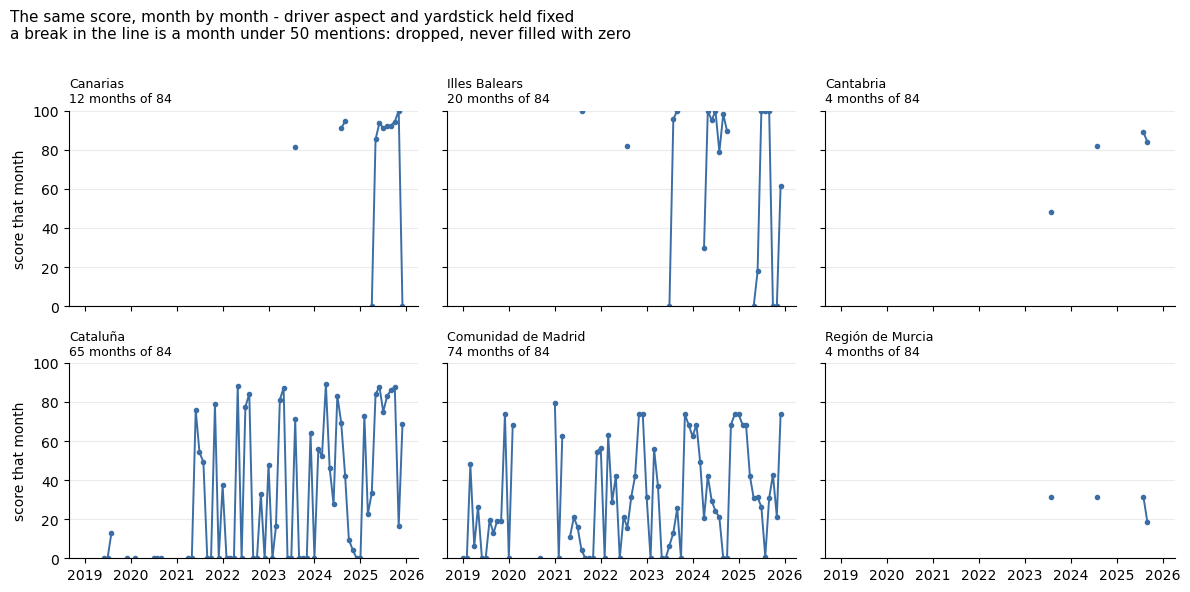

In [9]:
# one small panel per region, so the series can actually be read.
# The six highest-scoring regions that have any trajectory at all.
show = [c for c in score.sort_values("score", ascending=False).ccaa if c in set(trend.ccaa)][:6]

# every month in the window, so a missing month becomes a real GAP in the line
# instead of a straight segment drawn across it
all_months = pd.period_range(FIRST, LAST, freq="M")

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey=True)
for ax, region in zip(axes.flat, show):
    s = (trend[trend.ccaa == region].set_index("period").score
         .reindex(all_months.astype(str)))                    # missing month -> NaN -> gap
    ax.plot(all_months.to_timestamp(), s.values,
            marker="o", markersize=3, linewidth=1.4, color="#3b6ea5")
    ax.set_title(f"{region}\n{s.notna().sum()} months of {len(all_months)}",
                 fontsize=9, loc="left")
    ax.set_ylim(0, 100)
    ax.grid(axis="y", alpha=.25)
    ax.spines[["top", "right"]].set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel("score that month")

fig.suptitle("The same score, month by month - driver aspect and yardstick held fixed\n"
             f"a break in the line is a month under {MIN_MENTIONS} mentions: "
             "dropped, never filled with zero",
             fontsize=11, x=.01, ha="left")
plt.tight_layout(rect=[0, 0, 1, .97]); plt.show()

## Step 6 — The same files, with Spanish column names

Role 6 builds the dashboard from these files and the thesis is written in Spanish, so the
columns need Spanish names.

**We do not rename the English files — we write a second copy of each.** A column name is an
interface: the moment Role 6 writes `df.score`, renaming that column breaks their code
*silently*. The file still loads, it just has no `score` in it any more. A second copy costs
one `rename()` and removes the risk.

Two rules keep the copies trustworthy:

- **Only the headers are translated, never the values.** `evidence` still says `solid` /
  `thin` in both. Translating values too would let the copies drift apart.
- **A column with no Spanish name stops the notebook.** That is what the `assert` is for.

In [10]:
TWINS = {"opportunity_score.csv":         "opportunity_score_es.csv",
         "opportunity_score_mensual.csv": "opportunity_score_mensual_es.csv"}

for english, spanish in TWINS.items():
    table   = pd.read_csv(OUT / english)
    missing = [c for c in table.columns if c not in COLUMNAS_ES]
    assert not missing, f"{english}: no Spanish name for {missing} - add it to COLUMNAS_ES"

    table.rename(columns=COLUMNAS_ES).to_csv(OUT / spanish, index=False)
    print(f"{english:<32} -> {spanish:<34} {len(table):>4} rows")

head = pd.read_csv(OUT / "opportunity_score.csv", nrows=0).columns
print("\n", pd.DataFrame({"english": head,
                          "espanol": [COLUMNAS_ES[c] for c in head]}).to_string(index=False))

opportunity_score.csv            -> opportunity_score_es.csv             19 rows
opportunity_score_mensual.csv    -> opportunity_score_mensual_es.csv    320 rows

            english             espanol
              rank              puesto
              ccaa                ccaa
             score          puntuacion
          pressure   presion_turistica
     driver_aspect       aspecto_motor
                 z                   z
            signal               senal
          mentions           menciones
         negatives           negativas
     negative_rate       tasa_negativa
          evidence           evidencia
          driver_2           aspecto_2
               z_2                 z_2
          signal_2             senal_2
        mentions_2         menciones_2
       negatives_2         negativas_2
   negative_rate_2     tasa_negativa_2
        evidence_2         evidencia_2
             z_gap        diferencia_z
   driver_is_close      empate_tecnico
n_rankable_aspect

## Step 7 — Check it

Every number above is worked out again here, **from the saved CSVs** rather than from memory.
If any line says `FAIL`, do not use the results.

In [11]:
saved   = pd.read_csv(OUT / "opportunity_score.csv")
monthly_saved = pd.read_csv(OUT / "opportunity_score_mensual.csv")
results = {}

results["all 19 regions are there, one row each"] = (
    len(saved) == 19 and saved.ccaa.is_unique)
results["score stays between 0 and 100"]   = saved.score.between(0, 100).all()
results["score = pressure x signal x 100"] = np.allclose(
    saved.score, saved.pressure * saved.signal * 100)
results["signal = erf(z/sqrt2), 0 if not above average"] = np.allclose(
    saved.signal, [erf(max(v, 0) / sqrt(2)) for v in saved.z])
results["negative_rate = negatives / mentions"] = np.allclose(
    saved.negative_rate, saved.negatives / saved.mentions)

ranked = area[area.can_rank]
results["every driver has the highest z of its region"] = all(
    np.isclose(ranked[ranked.ccaa == r.ccaa].z.max(), r.z) for r in saved.itertuples())
results["every runner-up has the second highest z"] = all(
    np.isclose(sorted(ranked[ranked.ccaa == r.ccaa].z, reverse=True)[1], r.z_2)
    for r in saved.dropna(subset=["driver_2"]).itertuples())
results["every driver clears the 50-mention floor"] = (saved.mentions >= MIN_MENTIONS).all()
results["z_gap and driver_is_close agree with z and z_2"] = (
    np.allclose(saved.z_gap.dropna(), (saved.z - saved.z_2).dropna())
    and (saved.driver_is_close == (saved.z_gap < CLOSE_GAP).fillna(False)).all())
results["mentions add up to the raw file"] = area.mentions.sum() == TOTAL_MENTIONS

# --- the monthly file, checked the same way ---
results["monthly: score = pressure x signal x 100"] = np.allclose(
    monthly_saved.score, monthly_saved.pressure * monthly_saved.signal * 100)
results["monthly: every row uses its region's own driver"] = (
    monthly_saved.ccaa.map(saved.set_index("ccaa").driver_aspect)
    == monthly_saved.driver_aspect).all()
results["monthly: every row clears the 50-mention floor"] = (
    monthly_saved.mentions >= MIN_MENTIONS).all()
results["monthly: every month is inside the window"] = (
    monthly_saved.period.between(FIRST, LAST).all())
results["monthly: yardstick is the frozen one from Step 3"] = (
    np.allclose(monthly_saved.average_region, monthly_saved.driver_aspect.map(yardstick["mean"]))
    and np.allclose(monthly_saved.spread, monthly_saved.driver_aspect.map(yardstick["std"])))

# --- the Spanish copies are a header rename and nothing else ---
for english, spanish in TWINS.items():
    en, es = pd.read_csv(OUT / english), pd.read_csv(OUT / spanish)
    results[f"{spanish} is {english} with Spanish headers only"] = (
        en.shape == es.shape
        and list(es.columns) == [COLUMNAS_ES[c] for c in en.columns]
        and en.astype(str).values.tolist() == es.astype(str).values.tolist())

for name, passed in results.items():
    print(f"{'PASS' if passed else 'FAIL'}  {name}")
print(f"\n{sum(results.values())}/{len(results)} checks passed")
assert all(results.values()), "a check failed - do not use these results"

thin = saved[saved.evidence == "thin"]
print(f"\n{len(thin)} of 19 regions rest on fewer than {FEW_NEGATIVE} complaints.")
print("They are ranked, but do not quote them as findings:")
print(thin[["rank", "ccaa", "driver_aspect", "mentions", "negatives"]].to_string(index=False))

close = saved[saved.driver_is_close]
print(f"\n{len(close)} of 19 regions have a near tie for the driver (z gap < {CLOSE_GAP}).")
print("Name both aspects when you talk about these:")
print(close[["rank", "ccaa", "driver_aspect", "driver_2", "z", "z_2", "z_gap"]]
      .round(3).to_string(index=False))

alone = saved[saved.n_rankable_aspects < 2]
if len(alone):
    print(f"\n{len(alone)} region(s) have only one eligible aspect, so no runner-up exists.")
    print("driver_is_close is False for them because there is nothing to be close TO -")
    print("n_rankable_aspects is the column that tells you so:")
    print(alone[["ccaa", "driver_aspect", "n_rankable_aspects"]].to_string(index=False))

PASS  all 19 regions are there, one row each
PASS  score stays between 0 and 100
PASS  score = pressure x signal x 100
PASS  signal = erf(z/sqrt2), 0 if not above average
PASS  negative_rate = negatives / mentions
PASS  every driver has the highest z of its region
PASS  every runner-up has the second highest z
PASS  every driver clears the 50-mention floor
PASS  z_gap and driver_is_close agree with z and z_2
PASS  mentions add up to the raw file
PASS  monthly: score = pressure x signal x 100
PASS  monthly: every row uses its region's own driver
PASS  monthly: every row clears the 50-mention floor
PASS  monthly: every month is inside the window
PASS  monthly: yardstick is the frozen one from Step 3
PASS  opportunity_score_es.csv is opportunity_score.csv with Spanish headers only
PASS  opportunity_score_mensual_es.csv is opportunity_score_mensual.csv with Spanish headers only

17/17 checks passed

6 of 19 regions rest on fewer than 20 complaints.
They are ranked, but do not quote them as

## What this score can and cannot claim

**It can** show which regions combine heavy tourism with an unusual complaint, name the aspect
responsible, say when that aspect was a near tie, and show every ingredient of the number — so
any ranking can be argued with rather than just displayed.

**It cannot yet be presented as a finding about Spanish tourism.** Every reason sits *upstream*
of this notebook:

1. **The sentiment is not really aspect-level.** Step 1 measures it every run: of the fragments
   carrying 2+ aspects, **0.00%** disagree. One label per fragment is copied onto every aspect
   in it. *(Role 1)*
2. **The aspect dictionary is Spanish-only** and English is ~42% of the corpus — Spanish reviews
   match 82% of the time, English 34%. That bias runs along the exact axis we rank on.
   *(Roles 1 and 2)*
3. **`masificacion` is barely found** — 0.07% of rows — which is awkward, because overcrowding
   is what the thesis is most about. *(Role 2)*
4. **Only 48% of reviews mention any aspect at all.**

Also for the write-up: complaints come mostly from Airbnb (87% of tagged rows) while the
official pressure counts regulated accommodation, so the two sides do not quite cover the same
market. And `period` may be the month a review was *published*, not the month of the stay.

**Ship this as a method demonstration.** The pipeline, the join and the checks are sound and
will not change when the input improves. Only the numbers will.

---

### What Session 13 added

Not the score — `opportunity_score.csv` is byte-identical to Session 12's. What was added sits
around it: the monthly view, the Spanish column copies, and `DICCIONARIO.md`, which is the
hand-over to Role 6.

`driver_is_close` was **already correct**: it exists at `CLOSE_GAP = 0.25` and Castilla y León,
the 0.011 near-tie, is already flagged `True`. Step 7 prints all four flagged regions every run.

### Where this sits in the team architecture

This notebook produces number **1 of 3**, and only number 1:

| | number | level | owner |
|---|---|---|---|
| **1** | **Regional Opportunity Score** | **one row per region** | **Role 5 — this notebook** |
| 2 | Relative Volume | one row per place | specified by Role 5, built by the engine owner |
| 3 | Recommendation Score | one place × one traveller | the engine owner |

**Never put this score inside the recommendation formula.** A region-level problem indicator
cannot tell an engine whether one hotel is a suitable, underused alternative for one traveller.